# 06 — O1 : mobilité (national)

Ce notebook **montre** les données de O1. Il ne produit aucun chiffre du 06 : ces chiffres viennent des CSV écrits par `scripts/exploration_06.py` (`data/analysis/06_exploration/`) et des tables du 05 (R-19). Il n'applique aucun seuil du 02, ne classe pas et ne calcule aucun score. Un écart est décrit, pas expliqué ; une date de la chronologie est une coïncidence, pas une cause (H1).

**Ce qu'on regarde** : les immatriculations par groupe (1990–2024), leurs parts, les permis par catégorie (2007–2024, sans 2013), immatriculations et permis catégorie par catégorie, les taux par habitant, le parc estimé et la population.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display
from style_06 import *
appliquer_style()
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)

In [2]:
GROUPES = ["Moto", "Voiture", "Poids lourd", "Bus et car", "Autres"]
d1 = lire("D1_immatriculations")
imm = d1.pivot_table(index="Année", columns="Groupe", values="Immatriculations", aggfunc="sum")[GROUPES]
ruptures_d1 = sorted(d1.loc[d1["Rupture"], "Année"].unique())
chrono = pd.read_csv(REFERENCE / "chronologie_reformes.csv", dtype=str)
chrono = chrono[chrono["Type"] != "État des lois"]
annees_chrono = sorted({int(x[:4]) for x in chrono["Date"]})
d2 = lire("D2_permis")
permis = d2.pivot(index="Année", columns="Catégorie", values="Permis délivrés")
libelle = d2.drop_duplicates("Catégorie").set_index("Catégorie")["Libellé"]
ruptures_d2 = sorted(d2.loc[d2["Rupture"], "Année"].unique())

## Immatriculations de l'année, par groupe

Un flux, jamais un parc (05 §4). Traits verticaux : ruptures annotées au 05 (anomalie 3). ▲ : années de la chronologie. Cercles : variations atypiques (06 §4).

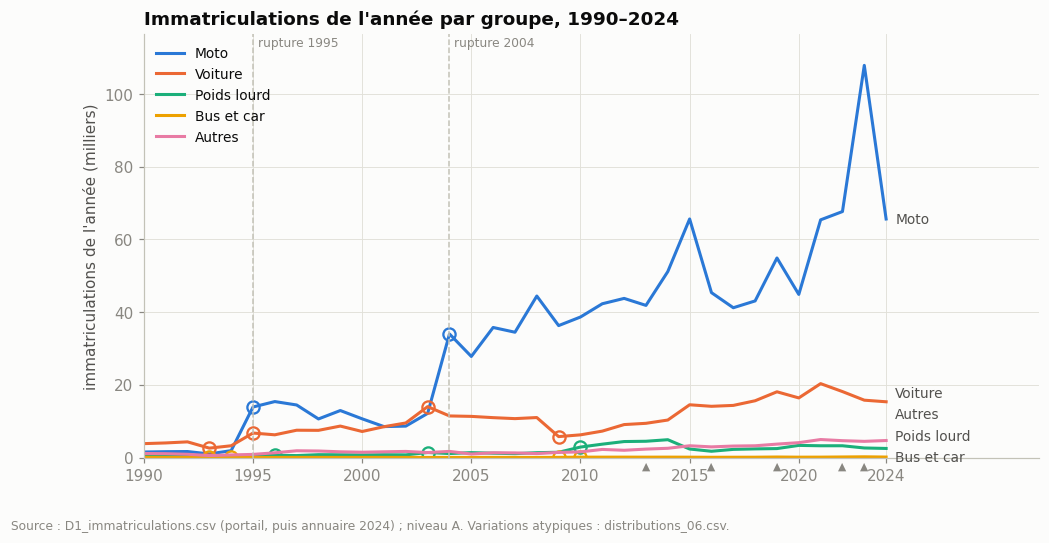

Groupe,Moto,Voiture,Poids lourd,Bus et car,Autres
Année,,,,,
1990,1513,3814,337,59,1106
1991,1601,4004,381,31,1052
1992,1641,4300,386,32,891
1993,982,2577,252,3,535
1994,1887,3227,271,29,710
1995,13883,6728,357,15,853
1996,15383,6239,621,16,1296
1997,14445,7503,529,28,1850
1998,10603,7470,774,35,1787


In [3]:
fig, ax = plt.subplots(figsize=(10.5, 5))
for couleur, g in zip(SERIES, GROUPES):
    ax.plot(imm.index, imm[g] / 1000, color=couleur, label=g)
    for an in annees_atypiques(f"Variation annuelle : immatriculations ({g})"):
        ax.plot(an, imm.at[an, g] / 1000, "o", ms=8, mfc="none", mec=couleur, mew=1.5)
ax.set_ylim(0, imm.max().max() / 1000 * 1.08)
for an in ruptures_d1:
    ax.axvline(an, color=AXE, linewidth=1, linestyle="--")
    ax.annotate(f"rupture {an}", (an, ax.get_ylim()[1] * 0.97), xytext=(3, 0), textcoords="offset points", fontsize=8, color=MUET)
for an in [a for a in annees_chrono if a <= imm.index.max()]:
    ax.annotate("▲", (an, 0), xytext=(0, -2), textcoords="offset points", ha="center", va="top", fontsize=7, color=MUET)
ax.set_xlim(imm.index.min(), imm.index.max() + 7)
ax.set_xticks(list(range(1990, 2021, 5)) + [2024])
etiquettes_fin(ax, imm.index[-1], {g: imm[g].iloc[-1] / 1000 for g in GROUPES})
ax.set_ylabel("immatriculations de l'année (milliers)")
ax.set_title("Immatriculations de l'année par groupe, 1990–2024")
ax.legend(loc="upper left", fontsize=9)
pied(fig, "Source : D1_immatriculations.csv (portail, puis annuaire 2024) ; niveau A. Variations atypiques : distributions_06.csv.")
plt.show()
display(imm)

## Part de chaque groupe (O1-02)

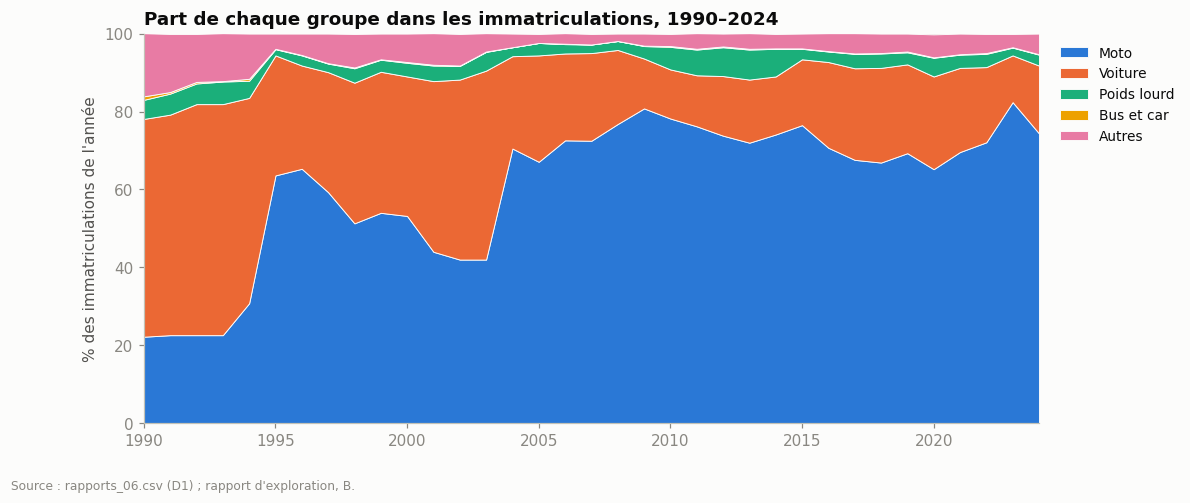

Catégorie,Moto,Voiture,Poids lourd,Bus et car,Autres
Année,,,,,
1990,22.2,55.9,4.9,0.9,16.2
1991,22.6,56.6,5.4,0.4,14.9
1992,22.6,59.3,5.3,0.4,12.3
1993,22.6,59.3,5.8,0.1,12.3
1994,30.8,52.7,4.4,0.5,11.6
1995,63.6,30.8,1.6,0.1,3.9
1996,65.3,26.5,2.6,0.1,5.5
1997,59.3,30.8,2.2,0.1,7.6
1998,51.3,36.1,3.7,0.2,8.6


In [4]:
part = serie("Part de chaque groupe")[GROUPES]
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.stackplot(part.index, part.T.values, colors=SERIES[:5], labels=GROUPES, edgecolor=SURFACE, linewidth=0.6)
ax.set_ylim(0, 100); ax.set_xlim(part.index.min(), part.index.max())
ax.set_ylabel("% des immatriculations de l'année")
ax.set_title("Part de chaque groupe dans les immatriculations, 1990–2024")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
pied(fig, "Source : rapports_06.csv (D1) ; rapport d'exploration, B.")
plt.show()
display(part)

## Permis délivrés, par catégorie

Un panneau par catégorie, chacun avec son axe. 2013 n'est pas renseignée (R-10) : la courbe s'interrompt. Traits verticaux : ruptures annotées au 05.

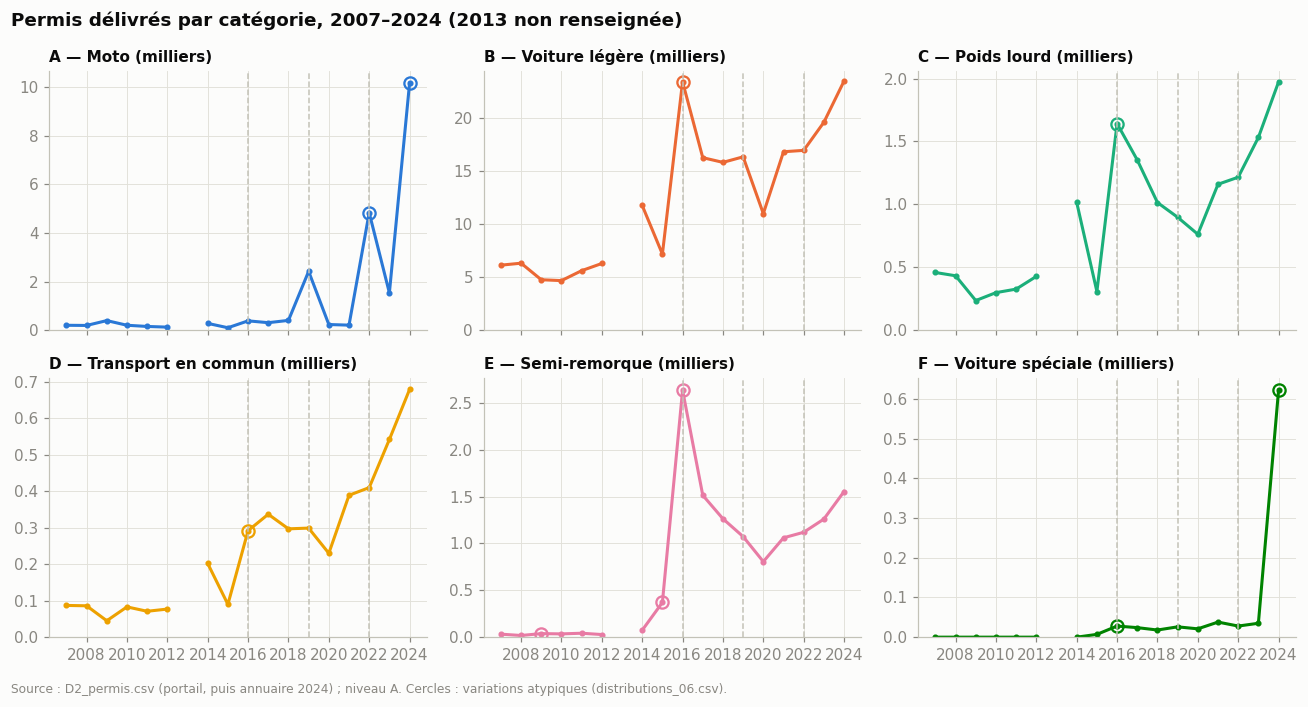

Catégorie,A,B,C,D,E,F
Année,,,,,,
2007,205,6148,459,87,32,0
2008,198,6334,433,86,18,0
2009,398,4771,236,45,38,0
2010,206,4690,299,83,35,0
2011,157,5628,327,71,42,0
2012,129,6307,428,77,28,0
2013,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2014,283,11787,1016,202,74,0
2015,104,7193,308,90,370,7


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.2), sharex=True)
for ax, couleur, cat in zip(axes.flat, SERIES, permis.columns):
    ax.plot(permis.index, permis[cat] / 1000, color=couleur, marker="o", markersize=3)
    for an in annees_atypiques(f"Variation annuelle : permis délivrés ({cat})"):
        ax.plot(an, permis.at[an, cat] / 1000, "o", ms=8, mfc="none", mec=couleur, mew=1.5)
    for an in ruptures_d2:
        ax.axvline(an, color=AXE, linewidth=1, linestyle="--")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{cat} — {libelle[cat]} (milliers)", fontsize=10)
    axe_annees(ax)
fig.suptitle("Permis délivrés par catégorie, 2007–2024 (2013 non renseignée)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
pied(fig, "Source : D2_permis.csv (portail, puis annuaire 2024) ; niveau A. Cercles : variations atypiques (distributions_06.csv).")
plt.show()
display(permis.astype("Int64"))

## Immatriculations et permis, catégorie par catégorie (O1-09)

Correspondance du 05 (`correspondance_vehicules_permis.csv`). F n'a pas de type immatriculé à part. Même unité dans chaque panneau : un seul axe.

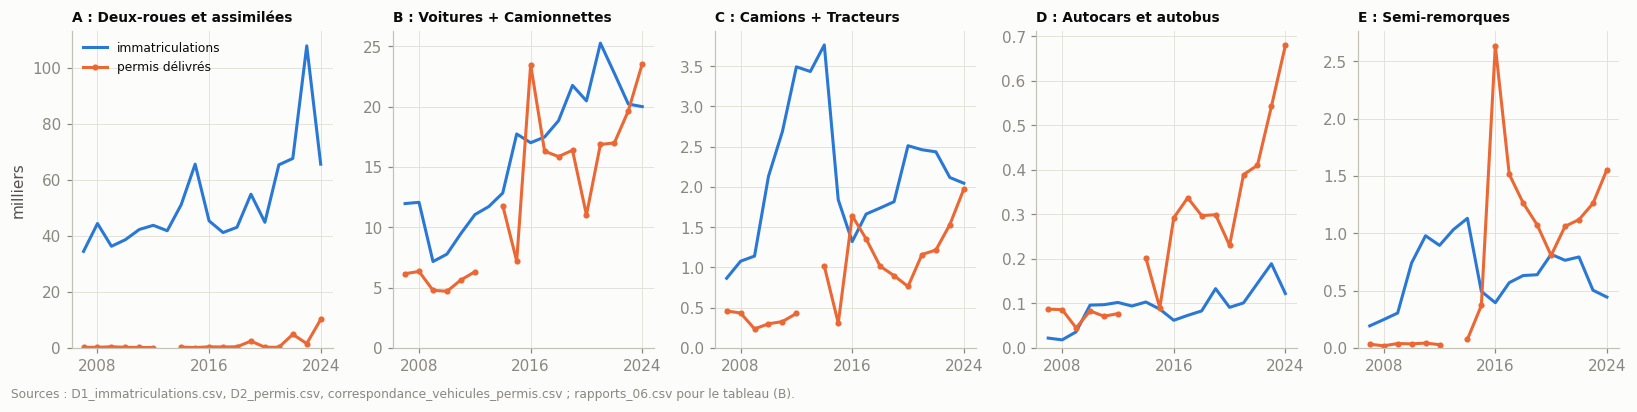

Catégorie,A,B,C,D,E
Année,,,,,
2007,168.07,1.95,1.88,0.25,6.00
2008,224.29,1.90,2.49,0.21,13.72
2009,91.15,1.50,4.83,0.80,8.00
2010,187.56,1.66,7.13,1.16,21.17
2011,269.32,1.68,8.23,1.37,23.29
2012,339.20,1.75,8.16,1.32,31.93
2014,180.69,1.09,3.70,0.51,15.27
2015,630.76,2.46,5.97,0.97,1.33
2016,117.16,0.72,0.80,0.21,0.15


,Année,Catégorie,Numérateur,Dénominateur,Valeur,Note
816,2007–2024,A,892305.0,22197.0,40.20,"cumul des années communes, sans 2013 ; Deux-roues et assimilées"
834,2007–2024,B,273776.0,212897.0,1.29,"cumul des années communes, sans 2013 ; Voitures + Camionnettes"
852,2007–2024,C,35112.0,15058.0,2.33,"cumul des années communes, sans 2013 ; Camions + Tracteurs"
870,2007–2024,D,1560.0,4216.0,0.37,"cumul des années communes, sans 2013 ; Autocars et autobus"
888,2007–2024,E,10530.0,12921.0,0.81,"cumul des années communes, sans 2013 ; Semi-remorques"


In [6]:
corr = pd.read_csv(REFERENCE / "correspondance_vehicules_permis.csv", keep_default_na=False)
corr = corr[corr["Types immatriculés (D1)"] != ""]
par_type = d1.pivot_table(index="Année", columns="Type", values="Immatriculations", aggfunc="sum").loc[2007:]
fig, axes = plt.subplots(1, len(corr), figsize=(15, 3.6), sharex=True)
for ax, (_, c) in zip(axes, corr.iterrows()):
    types = [t.strip() for t in c["Types immatriculés (D1)"].split("|")]
    ax.plot(par_type.index, par_type[types].sum(axis=1) / 1000, color=SERIES[0], label="immatriculations")
    ax.plot(permis.index, permis[c["Catégorie"]] / 1000, color=SERIES[1], marker="o", markersize=3, label="permis délivrés")
    ax.set_ylim(bottom=0); ax.set_xticks([2008, 2016, 2024])
    ax.set_title(f"{c['Catégorie']} : {' + '.join(types)}", fontsize=9)
axes[0].set_ylabel("milliers"); axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
pied(fig, "Sources : D1_immatriculations.csv, D2_permis.csv, correspondance_vehicules_permis.csv ; rapports_06.csv pour le tableau (B).")
plt.show()
r = rapport("Immatriculations pour un permis délivré")
display(serie("Immatriculations pour un permis délivré"))
display(r[r["Année"].astype(str).str.contains("–")][["Année", "Catégorie", "Numérateur", "Dénominateur", "Valeur", "Note"]])

## Taux par habitant (O1-04, O1-07)

La population n'est mesurée (A) qu'en 2010 et 2022 : les autres années sont en C (R-06). Deux panneaux, un axe chacun.

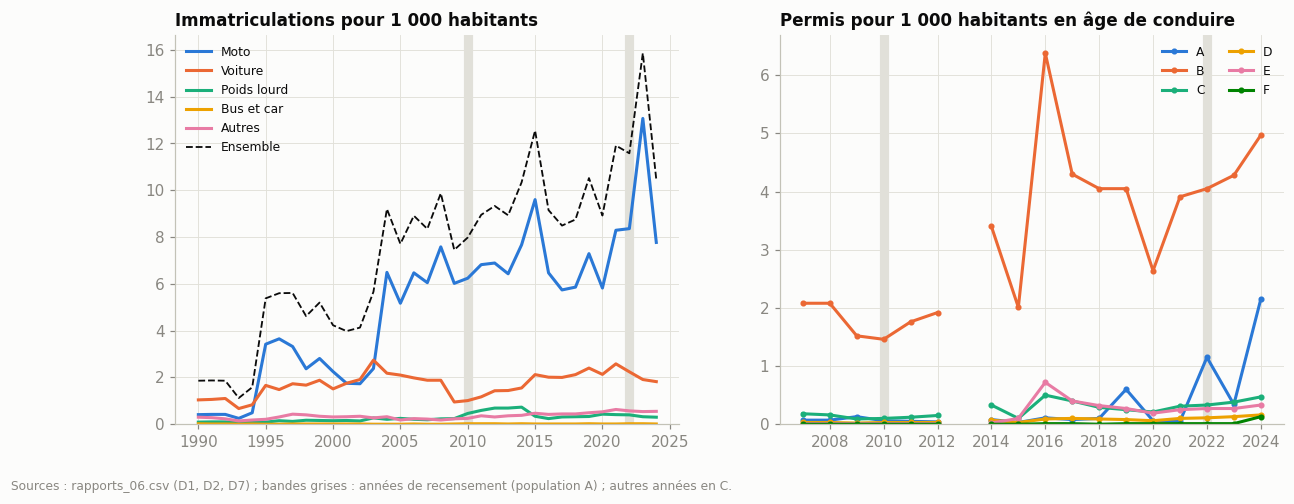

Catégorie,Autres,Bus et car,Ensemble,Moto,Poids lourd,Voiture
Année,,,,,,
2010,0.25,0.02,7.98,6.24,0.46,1.01
2011,0.36,0.02,8.95,6.82,0.59,1.17
2012,0.31,0.02,9.33,6.89,0.69,1.43
2013,0.36,0.01,8.93,6.43,0.69,1.44
2014,0.38,0.02,10.34,7.67,0.73,1.55
2015,0.47,0.01,12.55,9.60,0.34,2.12
2016,0.42,0.01,9.15,6.47,0.24,2.01
2017,0.44,0.01,8.49,5.74,0.31,2.00
2018,0.44,0.01,8.75,5.86,0.32,2.12


Catégorie,A,B,C,D,E,F
Année,,,,,,
2007,0.07,2.08,0.18,0.03,0.01,0.00
2008,0.07,2.08,0.16,0.03,0.01,0.00
2009,0.13,1.52,0.09,0.02,0.01,0.00
2010,0.06,1.46,0.10,0.03,0.01,0.00
2011,0.05,1.76,0.12,0.03,0.01,0.00
2012,0.04,1.92,0.15,0.03,0.01,0.00
2013,NaN,NaN,NaN,NaN,NaN,NaN
2014,0.08,3.40,0.33,0.07,0.02,0.00
2015,0.03,2.01,0.10,0.03,0.10,0.00


In [7]:
o104 = serie("Immatriculations pour 1 000 habitants")
o107 = serie("Permis pour 1 000 habitants en âge de conduire")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
for couleur, g in zip(SERIES, GROUPES):
    a1.plot(o104.index, o104[g], color=couleur, label=g)
a1.plot(o104.index, o104["Ensemble"], color=ENCRE, linewidth=1.2, linestyle="--", label="Ensemble")
for an in (2010, 2022):
    for a in (a1, a2):
        a.axvline(an, color=GRILLE, linewidth=6, zorder=0)
a1.set_title("Immatriculations pour 1 000 habitants", fontsize=11); a1.legend(fontsize=8); a1.set_ylim(bottom=0)
for couleur, cat in zip(SERIES, o107.columns):
    a2.plot(o107.index, o107[cat], color=couleur, marker="o", markersize=3, label=cat)
a2.set_title("Permis pour 1 000 habitants en âge de conduire", fontsize=11); a2.legend(fontsize=8, ncol=2); a2.set_ylim(bottom=0)
axe_annees(a2)
pied(fig, "Sources : rapports_06.csv (D1, D2, D7) ; bandes grises : années de recensement (population A) ; autres années en C.")
plt.show()
display(o104.loc[2010:]); display(o107)

## Parc estimé (O1-05)

Cumul des immatriculations sur la durée de vie PA-01 ; bande : bornes basse et haute (C). Une année sans fenêtre complète reste vide (05 §6).

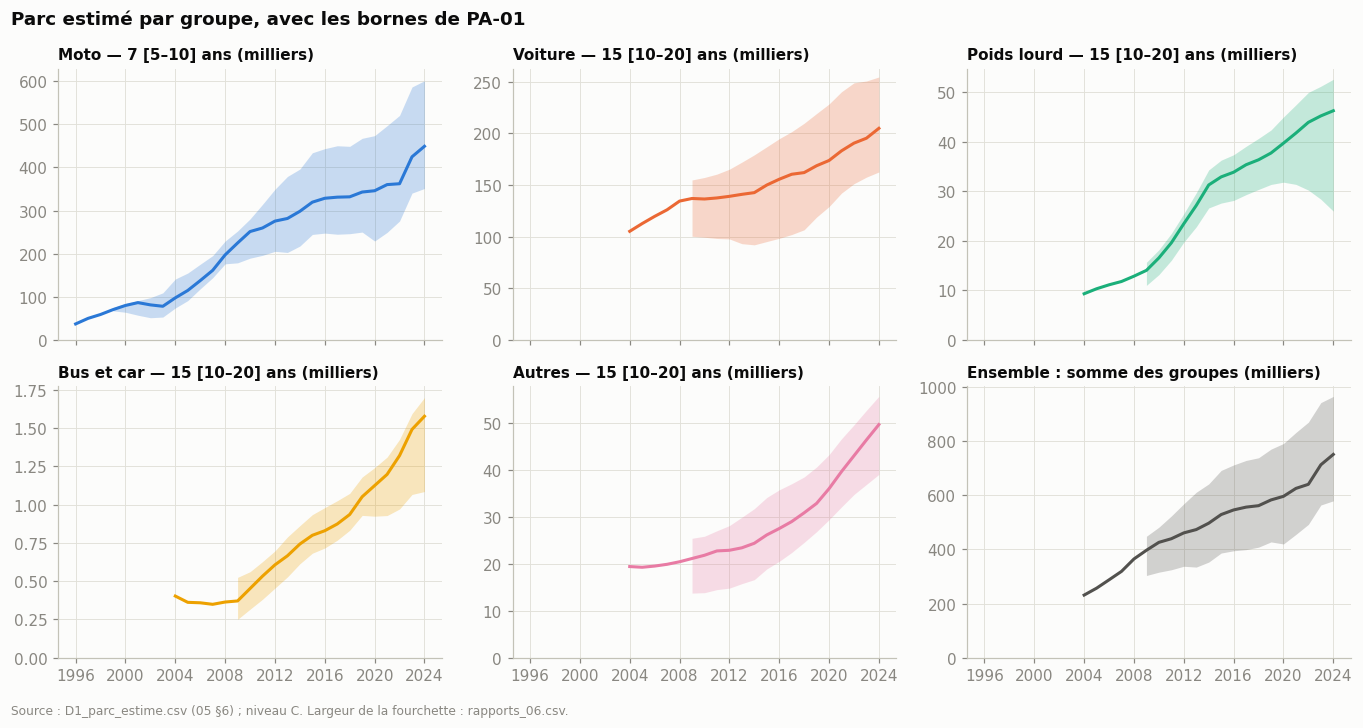

Catégorie,Autres,Bus et car,Ensemble,Moto,Poids lourd,Voiture
Année,,,,,,
2009,55.2,73.9,36.5,32.9,33.2,39.8
2014,62.0,33.5,58.1,59.9,24.6,61.1
2019,41.9,23.9,58.8,63.4,29.1,59.5
2022,34.5,34.4,58.9,67.6,44.9,51.3
2024,33.5,38.9,51.4,55.7,57.6,44.9


In [8]:
parc = lire("D1_parc_estime")
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.4), sharex=True)
for ax, couleur, g in zip(axes.flat, SERIES[:5] + [ENCRE_2], GROUPES + ["Ensemble"]):
    s = parc[parc["Groupe"] == g].set_index("Année")
    ax.fill_between(s.index, s["Borne basse"] / 1000, s["Borne haute"] / 1000, color=couleur, alpha=0.25, linewidth=0)
    ax.plot(s.index, s["Valeur centrale"] / 1000, color=couleur)
    ax.set_title(f"{g} — {s['Durée de vie PA-01 (ans)'].iloc[0]} ans (milliers)" if g != "Ensemble" else "Ensemble : somme des groupes (milliers)", fontsize=10)
    ax.set_ylim(bottom=0); axe_annees(ax)
fig.suptitle("Parc estimé par groupe, avec les bornes de PA-01", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
pied(fig, "Source : D1_parc_estime.csv (05 §6) ; niveau C. Largeur de la fourchette : rapports_06.csv.")
plt.show()
display(serie("Largeur de la fourchette du parc estimé").loc[[2009, 2014, 2019, 2022, 2024]])

## Population nationale

Source de chaque année (05 §4, D7). Cercles : variations atypiques (06 §4) : les raccords entre sources se voient-ils ?

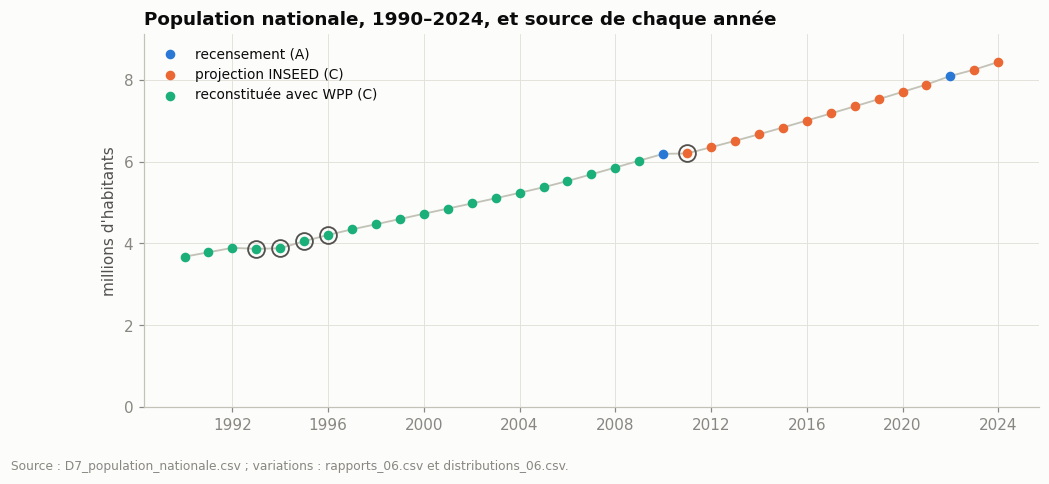

Année,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Catégorie,,,,,,,,,,,,,,,,,,,,,
Togo,2.9,2.9,-0.6,0.4,4.4,3.8,3.2,2.9,2.9,2.8,...,2.5,2.5,2.5,2.4,2.4,2.4,2.3,2.7,1.9,2.3


In [9]:
pop = lire("D7_population_nationale").set_index("Année")
origine = pop["Source"].str.split(" ").str[0].map({"recensement": "recensement (A)", "projections": "projection INSEED (C)", "reconstituée": "reconstituée avec WPP (C)"})
fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.plot(pop.index, pop["Population"] / 1e6, color=AXE, linewidth=1.2, zorder=1)
for couleur, o in zip(SERIES, ["recensement (A)", "projection INSEED (C)", "reconstituée avec WPP (C)"]):
    s = pop[origine == o]
    ax.scatter(s.index, s["Population"] / 1e6, color=couleur, s=28, label=o, zorder=2)
for an in annees_atypiques("Variation annuelle : population (Togo)"):
    ax.plot(an, pop.at[an, "Population"] / 1e6, "o", ms=11, mfc="none", mec=ENCRE_2, mew=1.2)
ax.set_ylim(0, pop["Population"].max() / 1e6 * 1.08); axe_annees(ax)
ax.set_ylabel("millions d'habitants"); ax.legend(fontsize=9)
ax.set_title("Population nationale, 1990–2024, et source de chaque année")
pied(fig, "Source : D7_population_nationale.csv ; variations : rapports_06.csv et distributions_06.csv.")
plt.show()
display(serie("Variation annuelle : population").T)

## Signaux de O1 (`signaux_06.csv`)

In [10]:
display(signaux(objectif="O1"))

,Résumé,Niveau,Question transmise
ID,,,
SIG-01,"Variation annuelle : immatriculations (Moto) : variation atypique en 1995, 2004. Chronologie la même année : aucune",B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
SIG-02,"Variation annuelle : immatriculations (Voiture) : variation atypique en 1993, 1995, 2003, 2009. Chronologie la même année : aucune",B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
SIG-03,"Variation annuelle : immatriculations (Poids lourd) : variation atypique en 1996, 2003, 2010. Chronologie la même année : aucune",B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
SIG-04,"Variation annuelle : immatriculations (Bus et car) : variation atypique en 1993, 1994, 2009, 2010. Chronologie la même année : aucune",B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
SIG-05,"Variation annuelle : permis délivrés (A) : variation atypique en 2022, 2024. Chronologie la même année : 2022 : Décret de création de l’...",B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
SIG-06,Variation annuelle : permis délivrés (B) : variation atypique en 2016. Chronologie la même année : 2016 : Adoption de la Charte africain...,B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
SIG-07,Variation annuelle : permis délivrés (C) : variation atypique en 2016. Chronologie la même année : 2016 : Adoption de la Charte africain...,B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
SIG-08,Variation annuelle : permis délivrés (D) : variation atypique en 2016. Chronologie la même année : 2016 : Adoption de la Charte africain...,B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
SIG-09,"Variation annuelle : permis délivrés (E) : variation atypique en 2009, 2015, 2016. Chronologie la même année : 2016 : Adoption de la Cha...",B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
